### This notebook requires a GPU runtime to run.
### Please select the menu option "Runtime" -> "Change runtime type", select "Hardware Accelerator" -> "GPU" and click "SAVE"

----------------------------------------------------------------------

# ResNet50

*Author: NVIDIA*

**ResNet50 model trained with mixed precision using Tensor Cores.**

<img src="https://pytorch.org/assets/images/classification.jpg" alt="alt" width="50%"/>


### Model Description

The **_ResNet50 v1.5_** model is a modified version of the [original ResNet50 v1 model](https://arxiv.org/abs/1512.03385).

The difference between v1 and v1.5 is that, in the bottleneck blocks which requires
downsampling, v1 has stride = 2 in the first 1x1 convolution, whereas v1.5 has stride = 2 in the 3x3 convolution.

This difference makes ResNet50 v1.5 slightly more accurate (\~0.5% top1) than v1, but comes with a small performance drawback (\~5% imgs/sec).

The model is initialized as described in [Delving deep into rectifiers: Surpassing human-level performance on ImageNet classification](https://arxiv.org/pdf/1502.01852.pdf)

This model is trained with mixed precision using Tensor Cores on Volta, Turing, and the NVIDIA Ampere GPU architectures. Therefore, researchers can get results over 2x faster than training without Tensor Cores, while experiencing the benefits of mixed precision training. This model is tested against each NGC monthly container release to ensure consistent accuracy and performance over time.

Note that the ResNet50 v1.5 model can be deployed for inference on the [NVIDIA Triton Inference Server](https://github.com/triton-inference-server/server) using TorchScript, ONNX Runtime or TensorRT as an execution backend. For details check [NGC](https://ngc.nvidia.com/catalog/resources/nvidia:resnet_for_triton_from_pytorch)

### Example

In the example below we will use the pretrained **_ResNet50 v1.5_** model to perform inference on **_image_** and present the result.

To run the example you need some extra python packages installed. These are needed for preprocessing images and visualization.

In [1]:
!pip install validators matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 4.6 MB/s eta 0:00:00


In [2]:
import torch
from PIL import Image
import torchvision.transforms as transforms
import numpy as np
import json
import requests
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f'Using {device} for inference')

Using cuda for inference


Load the model pretrained on ImageNet dataset.

In [3]:
resnet50 = torch.hub.load('NVIDIA/DeepLearningExamples:torchhub', 'nvidia_resnet50', pretrained=True)
utils = torch.hub.load('NVIDIA/DeepLearningExamples:torchhub', 'nvidia_convnets_processing_utils')

resnet50.eval().to(device)

The repository NVIDIA_DeepLearningExamples does not belong to the list of trusted repositories and as such cannot be downloaded. Do you trust this repository and wish to add it to the trusted list of repositories (y/N)?y
Downloading: "https://github.com/NVIDIA/DeepLearningExamples/zipball/torchhub" to /root/.cache/torch/hub/torchhub.zip
Downloading: "https://api.ngc.nvidia.com/v2/models/nvidia/resnet50_pyt_amp/versions/20.06.0/files/nvidia_resnet50_200821.pth.tar" to /root/.cache/torch/hub/checkpoints/nvidia_resnet50_200821.pth.tar


100%|██████████| 97.7M/97.7M [00:00<00:00, 346MB/s]
Using cache found in /root/.cache/torch/hub/NVIDIA_DeepLearningExamples_torchhub


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layers): Sequential(
    (0): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0): Conv2d

Prepare sample input data.

In [4]:
uris = [
    'http://images.cocodataset.org/test-stuff2017/000000024309.jpg',
    'http://images.cocodataset.org/test-stuff2017/000000028117.jpg',
    'http://images.cocodataset.org/test-stuff2017/000000006149.jpg',
    'http://images.cocodataset.org/test-stuff2017/000000004954.jpg',
]

batch = torch.cat(
    [utils.prepare_input_from_uri(uri) for uri in uris]
).to(device)

Run inference. Use `pick_n_best(predictions=output, n=topN)` helper function to pick N most probably hypothesis according to the model.

In [5]:
with torch.no_grad():
    output = torch.nn.functional.softmax(resnet50(batch), dim=1)

results = utils.pick_n_best(predictions=output, n=5)

sample 0: [('laptop, laptop computer', '34.7%'), ('mouse, computer mouse', '11.9%'), ('notebook, notebook computer', '10.9%'), ('monitor', '3.9%'), ('web site, website, internet site, site', '3.1%')]
sample 1: [('mashed potato', '78.6%'), ('broccoli', '7.3%'), ('meat loaf, meatloaf', '2.5%'), ('plate', '1.8%'), ('guacamole', '0.2%')]
sample 2: [('racket, racquet', '25.4%'), ('tennis ball', '6.0%'), ('ping-pong ball', '2.0%'), ('catamaran', '0.3%'), ('bathtub, bathing tub, bath, tub', '0.3%')]
sample 3: [('groenendael', '12.7%'), ('Scottish deerhound, deerhound', '11.2%'), ('flat-coated retriever', '6.6%'), ('kelpie', '6.1%'), ('Great Dane', '3.1%')]


Display the result.

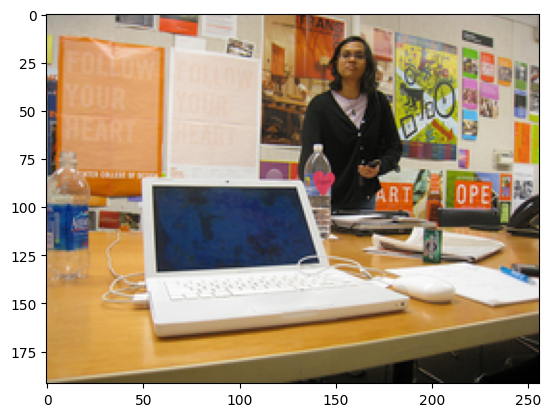

[('laptop, laptop computer', '34.7%'), ('mouse, computer mouse', '11.9%'), ('notebook, notebook computer', '10.9%'), ('monitor', '3.9%'), ('web site, website, internet site, site', '3.1%')]


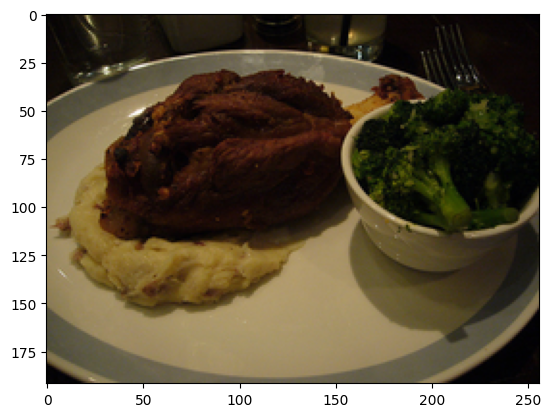

[('mashed potato', '78.6%'), ('broccoli', '7.3%'), ('meat loaf, meatloaf', '2.5%'), ('plate', '1.8%'), ('guacamole', '0.2%')]


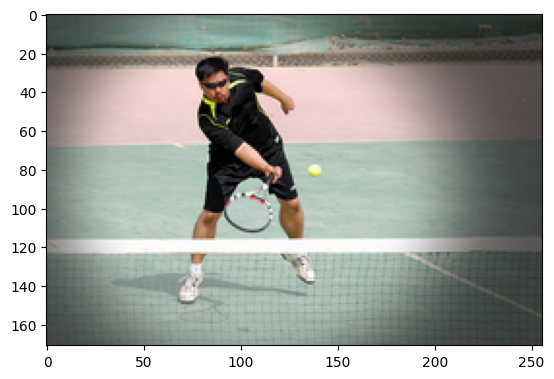

[('racket, racquet', '25.4%'), ('tennis ball', '6.0%'), ('ping-pong ball', '2.0%'), ('catamaran', '0.3%'), ('bathtub, bathing tub, bath, tub', '0.3%')]


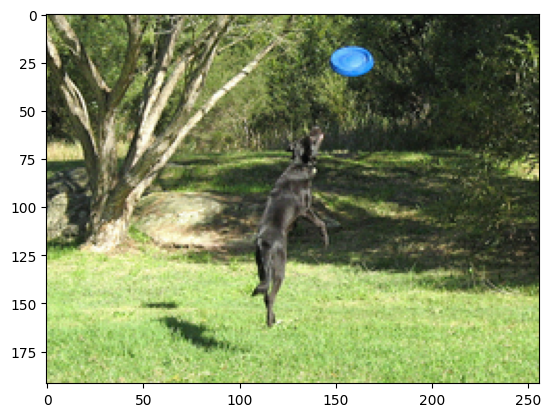

[('groenendael', '12.7%'), ('Scottish deerhound, deerhound', '11.2%'), ('flat-coated retriever', '6.6%'), ('kelpie', '6.1%'), ('Great Dane', '3.1%')]


In [6]:
for uri, result in zip(uris, results):
    img = Image.open(requests.get(uri, stream=True).raw)
    img.thumbnail((256,256), Image.LANCZOS)
    plt.imshow(img)
    plt.show()
    print(result)


### Details

For detailed information on model input and output, training recipies, inference and performance visit:
[github](https://github.com/NVIDIA/DeepLearningExamples/tree/master/PyTorch/Classification/ConvNets/resnet50v1.5)
and/or [NGC](https://ngc.nvidia.com/catalog/resources/nvidia:resnet_50_v1_5_for_pytorch)

### References

- [Original ResNet50 v1 paper](https://arxiv.org/abs/1512.03385)
- [Delving deep into rectifiers: Surpassing human-level performance on ImageNet classification](https://arxiv.org/pdf/1502.01852.pdf)
- [model on github](https://github.com/NVIDIA/DeepLearningExamples/tree/master/PyTorch/Classification/ConvNets/resnet50v1.5)
- [model on NGC](https://ngc.nvidia.com/catalog/resources/nvidia:resnet_50_v1_5_for_pytorch)
- [pretrained model on NGC](https://ngc.nvidia.com/catalog/models/nvidia:resnet50_pyt_amp)

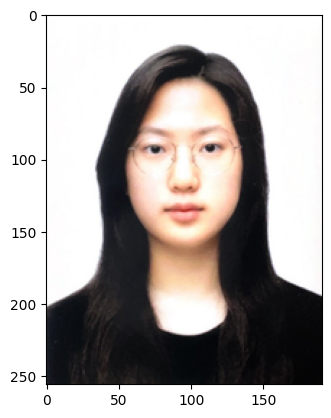

tensor([[[1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
         ...,
         [0.1059, 0.1098, 0.0980,  ..., 0.0196, 0.0196, 0.0157],
         [0.1294, 0.1137, 0.0902,  ..., 0.0235, 0.0235, 0.0157],
         [0.1333, 0.1137, 0.0941,  ..., 0.0196, 0.0196, 0.0235]],

        [[1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
         ...,
         [0.1255, 0.1255, 0.1098,  ..., 0.0196, 0.0196, 0.0157],
         [0.1490, 0.1294, 0.1020,  ..., 0.0235, 0.0235, 0.0157],
         [0.1490, 0.1294, 0.1059,  ..., 0.0196, 0.0196, 0.0235]],

        [[1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.

In [7]:
import torch
import torchvision
from PIL import Image
from matplotlib import pyplot as plt

fname = 'profile.jpg'
image = Image.open(fname)

image.thumbnail((256, 256), Image.Resampling.LANCZOS)

plt.imshow(image)
plt.show()

totensor = torchvision.transforms.ToTensor()
image_tensor = totensor(image)

print(image_tensor)

batch = image_tensor.unsqueeze(0).to(device)
print(batch.shape)

output = resnet50(batch)
print(output.shape)

probability = torch.nn.functional.softmax(output, dim=1)

top5 = utils.pick_n_best(probability.detach(), n=5)

print(top5)